In [ ]:

!pip install wandb -q
import wandb
wandb.login() # 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

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: 3_khia (3_khia-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Cài đặt thư viện mne
#!pip install mne

Mounted at /content/drive


**TIỀN XỬ LÍ DATA**


In [ ]:
#Cắt epoch và chuyển sang npz

import mne
import numpy as np
import os
import glob


# --- 1. CẤU HÌNH ĐƯỜNG DẪN ---
# Thư mục chứa 197 files gốc (có cả PSG và Hypnogram)
raw_data_dir = '/content/drive/MyDrive/sleep-edf-database-expanded-1.0.0/sleep-cassette'
# Thư mục sẽ lưu các file .npz sau khi cắt (Nhớ tạo thư mục này trên Drive trước)
output_dir = '/content/drive/MyDrive/Sleep-EDF-Processed/SC_Data'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# --- 2. HÀM CẮT EPOCH (Đã tối ưu để chạy ẩn, không in warning) ---
def process_patient(psg_path, hyp_path):
    mne.set_log_level('ERROR') # Tắt hết cảnh báo màu đỏ cho gọn màn hình
    raw = mne.io.read_raw_edf(psg_path, preload=True)
    annot = mne.read_annotations(hyp_path)
    raw.set_annotations(annot)
    raw.pick_channels(['EEG Pz-Oz'])

    annotation_desc_2_event_id = {
        'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2,
        'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4
    }
    events, event_id = mne.events_from_annotations(
        raw, event_id=annotation_desc_2_event_id, chunk_duration=30.0)

    tmax = 30. - 1. / raw.info['sfreq']
    epochs = mne.Epochs(raw=raw, events=events, event_id=event_id,
                        tmin=0., tmax=tmax, baseline=None, preload=True)

    X = epochs.get_data()
    Y = epochs.events[:, 2]

    # Chuẩn hóa Z-score
    mean = np.mean(X, axis=2, keepdims=True)
    std = np.std(X, axis=2, keepdims=True)
    X = (X - mean) / (std + 1e-7)

    return X, Y

# --- 3. VÒNG LẶP QUÉT TOÀN BỘ FILE ---
psg_files = glob.glob(os.path.join(raw_data_dir, '*PSG.edf'))
psg_files.sort()

print(f"Bắt đầu xử lý {len(psg_files)} bệnh nhân...")

for i, psg_path in enumerate(psg_files):
    basename = os.path.basename(psg_path)
    subject_night_id = basename[:6] # Lấy 6 ký tự đầu (vd: SC4001)

    # Tìm file nhãn tương ứng
    hyp_pattern = os.path.join(raw_data_dir, f"{subject_night_id}*Hypnogram.edf")
    hyp_matches = glob.glob(hyp_pattern)

    if len(hyp_matches) > 0:
        hyp_path = hyp_matches[0]
        out_file = os.path.join(output_dir, f"{subject_night_id}.npz")

        # Bỏ qua nếu đã xử lý rồi (Giúp chạy tiếp nếu bị đứt mạng)
        if os.path.exists(out_file):
            print(f"[{i+1}/{len(psg_files)}] Bỏ qua {subject_night_id} (Đã có sẵn)")
            continue

        try:
            X, Y = process_patient(psg_path, hyp_path)
            # Lưu mảng X và Y vào 1 file .npz duy nhất
            np.savez(out_file, x=X, y=Y)
            print(f"[{i+1}/{len(psg_files)}] Đã lưu thành công: {subject_night_id}.npz (X shape: {X.shape})")

            # GIẢI PHÓNG RAM QUAN TRỌNG (Đã sửa lỗi)
            del X, Y
        except Exception as e:
            print(f"[{i+1}/{len(psg_files)}] LỖI ở {subject_night_id}: {e}")

Bắt đầu xử lý 153 bệnh nhân...
[1/153] Bỏ qua SC4001 (Đã có sẵn)
[2/153] Đã lưu thành công: SC4002.npz (X shape: (2829, 1, 3000))
[3/153] Đã lưu thành công: SC4011.npz (X shape: (2802, 1, 3000))
[4/153] Đã lưu thành công: SC4012.npz (X shape: (2848, 1, 3000))
[5/153] Đã lưu thành công: SC4021.npz (X shape: (2804, 1, 3000))
[6/153] Đã lưu thành công: SC4022.npz (X shape: (2755, 1, 3000))
[7/153] Đã lưu thành công: SC4031.npz (X shape: (2820, 1, 3000))
[8/153] Đã lưu thành công: SC4032.npz (X shape: (2732, 1, 3000))
[9/153] Đã lưu thành công: SC4041.npz (X shape: (2569, 1, 3000))
[10/153] Đã lưu thành công: SC4042.npz (X shape: (2788, 1, 3000))
[11/153] Đã lưu thành công: SC4051.npz (X shape: (2722, 1, 3000))
[12/153] Đã lưu thành công: SC4052.npz (X shape: (2804, 1, 3000))
[13/153] Đã lưu thành công: SC4061.npz (X shape: (2770, 1, 3000))
[14/153] Đã lưu thành công: SC4062.npz (X shape: (2830, 1, 3000))
[15/153] Đã lưu thành công: SC4071.npz (X shape: (2810, 1, 3000))
[16/153] Đã lưu thà

In [ ]:
#cắt epoch thử
import mne
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

def extract_epochs(psg_path, hyp_path):
    print(f"Đang đọc dữ liệu từ: {psg_path}")

    # 1. Load dữ liệu PSG và Annotations (Nhãn)
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
    annot = mne.read_annotations(hyp_path)
    raw.set_annotations(annot, emit_warning=False)

    # 2. Lấy kênh Fpz-Cz
    raw.pick_channels(['EEG Fpz-Cz'])

    # 3. Tạo từ điển map nhãn (Gộp Stage 3 và 4 thành N3)
    # Lớp: 0=Wake, 1=N1, 2=N2, 3=N3, 4=REM
    annotation_desc_2_event_id = {
        'Sleep stage W': 0,
        'Sleep stage 1': 1,
        'Sleep stage 2': 2,
        'Sleep stage 3': 3,
        'Sleep stage 4': 3,
        'Sleep stage R': 4
    }

    # 4. Trích xuất các sự kiện (events) từ annotations
    events, event_id = mne.events_from_annotations(
        raw, event_id=annotation_desc_2_event_id, chunk_duration=30.0, verbose=False)

    # 5. Cắt Epoch (30 giây)
    tmax = 30. - 1. / raw.info['sfreq']  # sfreq = 100Hz -> 30s
    epochs = mne.Epochs(raw=raw, events=events, event_id=event_id,
                        tmin=0., tmax=tmax, baseline=None, preload=True, verbose=False)

    # Lấy dữ liệu X (sóng não) và Y (nhãn)
    X = epochs.get_data() # Kích thước: [số_epoch, 1_kênh, 3000_điểm]
    Y = epochs.events[:, 2] # Nhãn tương ứng

    # Chuẩn hóa Z-score cho X (giúp model hội tụ nhanh hơn)
    mean = np.mean(X, axis=2, keepdims=True)
    std = np.std(X, axis=2, keepdims=True)
    X = (X - mean) / (std + 1e-7)

    return X, Y

# --- THAY ĐƯỜNG DẪN Ở ĐÂY TRỎ VÀO DRIVE CỦA BẠN ---
# Ví dụ lấy bản ghi của người đầu tiên (Subject 0)
psg_file = '/content/drive/MyDrive/sleep-edf-database-expanded-1.0.0/sleep-cassette/SC4001E0-PSG.edf'
hyp_file = '/content/drive/MyDrive/sleep-edf-database-expanded-1.0.0/sleep-cassette/SC4001EC-Hypnogram.edf'

# Chạy hàm trích xuất
X_data, Y_data = extract_epochs(psg_file, hyp_file)

print(f"Hoàn thành! Kích thước X: {X_data.shape}") # Kỳ vọng: (N, 1, 3000)
print(f"Kích thước Y: {Y_data.shape}") # Kỳ vọng: (N,)

Đang đọc dữ liệu từ: /content/drive/MyDrive/sleep-edf-database-expanded-1.0.0/sleep-cassette/SC4001E0-PSG.edf


/tmp/ipykernel_4672/1765504444.py:12: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_4672/1765504444.py:12: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_4672/1765504444.py:12: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Hoàn thành! Kích thước X: (2650, 1, 3000)
Kích thước Y: (2650,)


In [ ]:
# TRAIN THỬ
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# --- 1. Chuyển Numpy array sang PyTorch Tensor ---
# Lưu ý: Chạy lại ô này bằng biến X_data, Y_data từ Cell 1
X_tensor = torch.tensor(X_data, dtype=torch.float32)
Y_tensor = torch.tensor(Y_data, dtype=torch.long)

# Tạo DataLoader (Batch size = 32)
dataset = TensorDataset(X_tensor, Y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# --- 2. Định nghĩa Model hoàn chỉnh ---
class DeepSleepNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=5):
        super(DeepSleepNet, self).__init__()

        # Nhánh nhỏ: kernel=50, stride=6
        self.small_cnn = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=50, stride=6),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=8, stride=8),
        )

        # Nhánh lớn: kernel=400, stride=50
        self.large_cnn = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=400, stride=50),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),
        )

        # Kích thước sau khi nối 2 nhánh (đã tính chính xác cho input 3000)
        concat_feature_size = 4736

        self.bilstm = nn.LSTM(
            input_size=concat_feature_size,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.classifier = nn.Linear(512, num_classes) # 256 * 2 (vì bidirectional)

    def forward(self, x):
        out_small = self.small_cnn(x)
        out_large = self.large_cnn(x)

        # Flatten
        out_small = out_small.view(out_small.size(0), -1)
        out_large = out_large.view(out_large.size(0), -1)

        # Concat
        out_concat = torch.cat((out_small, out_large), dim=1)
        out_concat = out_concat.unsqueeze(1)

        out_lstm, _ = self.bilstm(out_concat)
        out = self.classifier(out_lstm[:, -1, :])
        return out

# --- 3. Khởi tạo và Huấn luyện ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang train trên thiết bị: {device}")

model = DeepSleepNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

Đang train trên thiết bị: cuda
Epoch [1/5] - Loss: 0.9468 - Accuracy: 74.38%
Epoch [2/5] - Loss: 0.8285 - Accuracy: 75.36%
Epoch [3/5] - Loss: 0.5345 - Accuracy: 81.36%
Epoch [4/5] - Loss: 0.2841 - Accuracy: 91.28%
Epoch [5/5] - Loss: 0.2084 - Accuracy: 93.74%


In [ ]:
import shutil
import os
import time

# Thư mục gốc trên Drive (Hay bị đứt mạng)
drive_dir = '/content/drive/MyDrive/Sleep-EDF-Processed/Fpz-Cz/SC_Data'

# Ổ cứng cục bộ của Colab (Tốc độ bàn thờ, không bao giờ rớt mạng)
local_dir = '/content/local_fpzcz_data'

print("Đang đánh nguyên chuyến xe container chở Data từ Drive về Local SSD...")
start_time = time.time()

if not os.path.exists(local_dir):
    shutil.copytree(drive_dir, local_dir)
    print(f"✅ Đã dọn xong nhà! Thời gian: {time.time() - start_time:.2f} giây.")
else:
    print("✅ Dữ liệu đã có sẵn trên Local SSD, quất thôi!")

Đang đánh nguyên chuyến xe container chở Data từ Drive về Local SSD...
✅ Đã dọn xong nhà! Thời gian: 233.25 giây.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import glob
import os
import wandb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import time # Import time for retries
import torch.nn.functional as F


# ==========================================
# 1. ĐỊNH NGHĨA MÔ HÌNH (Có Sequence Context + Residual)
# ==========================================
class DeepSleepNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=5):
        super(DeepSleepNet, self).__init__()
        self.small_cnn = nn.Sequential(nn.Conv1d(in_channels, 64, 50, 6), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(8, 8))
        self.large_cnn = nn.Sequential(nn.Conv1d(in_channels, 64, 400, 50), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4, 4))

        self.bilstm = nn.LSTM(input_size=4736, hidden_size=256, num_layers=2, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(512 + 4736, num_classes)

    def forward(self, x):
        # x shape ban đầu: (batch_size, seq_len, 1, 3000)
        batch_size, seq_len, channels, length = x.size()

        # Làm phẳng để nạp vào CNN: (batch_size * seq_len, 1, 3000)
        x_flat = x.view(batch_size * seq_len, channels, length)

        out_small = self.small_cnn(x_flat).view(x_flat.size(0), -1)
        out_large = self.large_cnn(x_flat).view(x_flat.size(0), -1)

        # Đặc trưng CNN của tất cả các epoch
        cnn_features = torch.cat((out_small, out_large), dim=1)

        # Cuộn lại thành chuỗi thời gian cho LSTM: (batch_size, seq_len, 4736)
        cnn_features_seq = cnn_features.view(batch_size, seq_len, -1)

        out_lstm, _ = self.bilstm(cnn_features_seq)

        # Lấy output của epoch CUỐI CÙNG trong chuỗi
        lstm_last = self.dropout(out_lstm[:, -1, :])

        # Lấy feature CNN của epoch CUỐI CÙNG để nối tắt
        cnn_last = cnn_features_seq[:, -1, :]

        combined_features = torch.cat((lstm_last, cnn_last), dim=1)
        return self.classifier(combined_features)

# ==========================================
# 2. AUTO-DETECT DEVICE & SMART DATA LOADER
# ==========================================
processed_dir = '/content/local_fpzcz_data'
all_files = glob.glob(os.path.join(processed_dir, '*.npz'))
all_files.sort()

unique_subjects = list(set([os.path.basename(f)[:6] for f in all_files]))
unique_subjects.sort()

train_subs, temp_subs = train_test_split(unique_subjects, test_size=0.3, random_state=42)
val_subs, test_subs = train_test_split(temp_subs, test_size=0.5, random_state=42)

# --- PHÁT HIỆN PHẦN CỨNG THÔNG MINH ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_GPU = torch.cuda.is_available()

print(f"🖥️ THIẾT BỊ XỬ LÝ: {'GPU (CUDA)' if USE_GPU else 'CPU (System RAM)'}")

def load_data_smart(subject_list, files, device_name, is_gpu):
    X_tensors, Y_tensors = [], []
    for f in files:
        if os.path.basename(f)[:6] in subject_list:
            retries = 3
            for attempt in range(retries):
                try:
                    data = np.load(f)
                    if is_gpu:
                        # Chế độ Đại gia: Nạp thẳng vào VRAM GPU
                        X_tensors.append(torch.tensor(data['x'], dtype=torch.float32, device=device_name))
                        Y_tensors.append(torch.tensor(data['y'], dtype=torch.long, device=device_name))
                    else:
                        # Chế độ Tiết kiệm: Nạp vào RAM Hệ thống (CPU)
                        X_tensors.append(torch.tensor(data['x'], dtype=torch.float32))
                        Y_tensors.append(torch.tensor(data['y'], dtype=torch.long))
                    del data
                    break # Break out of retry loop if successful
                except ConnectionAbortedError as e:
                    print(f"⚠️ ConnectionAbortedError when loading {f}, attempt {attempt + 1}/{retries}. Retrying in 5 seconds...")
                    if attempt < retries - 1:
                        time.sleep(5)
                    else:
                        print(f"❌ Failed to load {f} after {retries} attempts due to ConnectionAbortedError: {e}")
                        raise # Re-raise if all retries fail
                except Exception as e:
                    print(f"❌ An unexpected error occurred when loading {f}: {e}")
                    raise # Re-raise for other unexpected errors

    if not X_tensors: return None, None
    return torch.cat(X_tensors, dim=0), torch.cat(Y_tensors, dim=0)


X_train, y_train = load_data_smart(train_subs, all_files, device, USE_GPU)
X_val, y_val = load_data_smart(val_subs, all_files, device, USE_GPU)
X_test, y_test = load_data_smart(test_subs, all_files, device, USE_GPU)

# ==========================================
# KHỐI MỚI: TẠO CHUỖI THỜI GIAN (SEQUENCE)
# ==========================================
SEQ_LEN = 5  # Số epoch liên tiếp LSTM được nhìn (5 x 30s = 2.5 phút)

class SequenceDataset(torch.utils.data.Dataset):
    # Thêm biến step=2 (nhảy cóc 2 epoch)
    def __init__(self, X, y, seq_len=5, step=2):
        self.X = X
        self.y = y
        self.seq_len = seq_len
        self.step = step

    def __len__(self):
        # Tính toán lại tổng số lượng mẫu dựa trên bước nhảy
        return (len(self.X) - self.seq_len) // self.step + 1

    def __getitem__(self, idx):
        # Nhân idx với bước nhảy để ra vị trí thực
        real_idx = idx * self.step
        x_seq = self.X[real_idx : real_idx + self.seq_len]

        if len(x_seq.shape) == 2:
            x_seq = x_seq.unsqueeze(1)
        elif len(x_seq.shape) > 3:
            x_seq = x_seq.view(self.seq_len, 1, -1)

        y_target = self.y[real_idx + self.seq_len - 1]
        return x_seq, y_target

def create_loader(X, y, batch_size=128, shuffle=True):
    if X is None: return None
    dataset = SequenceDataset(X, y, seq_len=SEQ_LEN, step=2) # Truyền step=2 vào

    # Kích hoạt đa luồng (num_workers) và băng thông rộng (pin_memory)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0)


train_loader = create_loader(X_train, y_train, shuffle=True)
val_loader = create_loader(X_val, y_val, shuffle=False)
test_loader = create_loader(X_test, y_test, shuffle=False)

# ==========================================
# 3. SETUP WANDB, CLASS WEIGHTS & OPTIMIZER
# ==========================================
y_train_np = y_train.cpu().numpy()
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_np), y=y_train_np)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
# ==========================================
# KHỐI MỚI: FOCAL LOSS TÍCH HỢP LABEL SMOOTHING
# ==========================================
class FocalLossWithSmoothing(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.1):
        super(FocalLossWithSmoothing, self).__init__()
        self.gamma = gamma
        self.smoothing = smoothing

    def forward(self, inputs, targets):
        num_classes = inputs.size(-1)
        log_probs = F.log_softmax(inputs, dim=-1)
        probs = torch.exp(log_probs)

        # 1. Label Smoothing
        targets_one_hot = torch.zeros_like(inputs).scatter_(1, targets.view(-1, 1), 1)
        targets_smooth = targets_one_hot * (1 - self.smoothing) + self.smoothing / num_classes

        # 2. Tính Focal Weight (dồn trọng số cho ca khó)
        pt = probs.gather(1, targets.view(-1, 1)).squeeze(1)
        focal_weight = (1 - pt) ** self.gamma

        # 3. Kết hợp Loss
        loss = -torch.sum(targets_smooth * log_probs, dim=-1)
        return (focal_weight * loss).mean()

wandb.init(
    project="sleep-staging-deep-learning",
    name="CNN-BiLSTM-continous-Training_Fpz_SC_1", # Đổi tên để dễ phân biệt trên WanDB
    save_code=True,
    config={
        # ⚠️ QUAN TRỌNG: Hạ Learning Rate xuống 10 lần (từ 1e-4 xuống 1e-5)
        # Vì model đã giỏi rồi, chỉ cần học "nhích" từng chút một thôi
        "learning_rate": 1e-5,
        "epochs": 50, # Chỉ cần train thêm khoảng 30 vòng
        "batch_size": 128,
        "weight_decay": 1e-4,
        "noise_std": 0.0,
        "device": str(device)
    }
)
config = wandb.config

# 1. Khởi tạo cái vỏ mô hình trống
model = DeepSleepNet().to(device)

# ==========================================
# KHỐI MỚI: BƠM LẠI "TRÍ NHỚ" TỪ FILE ĐÃ LƯU
# ==========================================
# Trỏ đường dẫn đến file best_model.pth của lần chạy 88.8% (Nhớ upload hoặc copy vào đúng chỗ)
checkpoint_path = 'best_model.pth'

if os.path.exists(checkpoint_path):
    print(f"🔄 Đang nạp lại tủy não từ {checkpoint_path}...")
    # Nạp trọng số vào mô hình
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print("✅ Nạp thành công! Sẵn sàng train tiếp (Fine-tuning).")
else:
    print("⚠️ Không tìm thấy file checkpoint. Sẽ train lại từ một tờ giấy trắng nhé!")
# ==========================================


criterion = FocalLossWithSmoothing(gamma=2.0, smoothing=0.1).to(device)
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# ==========================================
# 4. TRAINING LOOP VỚI KHẢ NĂNG LUÂN CHUYỂN DATA
# ==========================================
best_val_f1 = 0.0
patience_early_stop = 30
epochs_no_improve = 0

# KHỞI TẠO BỘ BƠM ĐẠO HÀM (GradScaler) CHO AMP
scaler = torch.amp.GradScaler('cuda')

print(f"Bắt đầu huấn luyện với AMP...")

for epoch in range(config.epochs):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        noise = torch.randn_like(inputs) * config.noise_std
        noisy_inputs = inputs + noise

        optimizer.zero_grad()

        # BẬT ÉP KIỂU TỰ ĐỘNG (Autocast xuống 16-bit)
        with torch.amp.autocast('cuda'):
            outputs = model(noisy_inputs)
            loss = criterion(outputs, labels)

        # DÙNG SCALER ĐỂ TÍNH ĐẠO HÀM & CẬP NHẬT TRỌNG SỐ
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Bật Autocast luôn ở Validation để suy luận nhanh hơn
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    # --- ĐÁNH GIÁ & GHI LOG (Giữ nguyên y hệt bản cũ) ---
    val_f1 = f1_score(all_targets, all_preds, average='macro')
    t_loss = train_loss / len(train_loader)
    v_loss = val_loss / len(val_loader)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d} | LR: {current_lr:.1e} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val F1: {val_f1:.4f}")
    wandb.log({"epoch": epoch+1, "Train Loss": t_loss, "Val Loss": v_loss, "Val F1": val_f1, "Learning Rate": current_lr})

    scheduler.step(val_f1)

    # --- MODEL CHECKPOINTING & EARLY STOPPING ---
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"🌟 Đã lưu Best Model mới! (F1: {best_val_f1:.4f})")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"⚠️ F1 không tăng {epochs_no_improve}/{patience_early_stop} epoch.")

    if epochs_no_improve >= patience_early_stop:
        print(f"🛑 Kích hoạt Early Stopping tại Epoch {epoch+1}.")
        break

# ==========================================
# 5. TEST VÀ NGHIỆM THU
# ==========================================
print("\n--- ĐÁNH GIÁ TRÊN TẬP TEST ---")
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

test_f1 = f1_score(test_targets, test_preds, average='macro')
print(f"🔥 FINAL TEST MACRO F1-SCORE: {test_f1:.4f}")
wandb.log({"Test Final F1": test_f1})
# ==========================================
# KHỐI MỚI: UPLOAD FILE LÊN WANDB
# ==========================================
print("☁️ Đang đồng bộ best_model.pth lên WanDB...")
# Tham số base_path='.' giúp WanDB hiểu file đang nằm cùng thư mục chạy code
wandb.save('best_model.pth', base_path='.')
print("✅ Upload hoàn tất! File đã nằm an toàn trên mây.")

wandb.finish()


🖥️ THIẾT BỊ XỬ LÝ: GPU (CUDA)


🔄 Đang nạp lại tủy não từ best_model.pth...
✅ Nạp thành công! Sẵn sàng train tiếp (Fine-tuning).
Bắt đầu huấn luyện với AMP...
Epoch 01 | LR: 1.0e-05 | Train Loss: 0.0374 | Val Loss: 0.2138 | Val F1: 0.7193
🌟 Đã lưu Best Model mới! (F1: 0.7193)
Epoch 02 | LR: 1.0e-05 | Train Loss: 0.0348 | Val Loss: 0.2170 | Val F1: 0.7064
⚠️ F1 không tăng 1/30 epoch.
Epoch 03 | LR: 1.0e-05 | Train Loss: 0.0328 | Val Loss: 0.2221 | Val F1: 0.7198
🌟 Đã lưu Best Model mới! (F1: 0.7198)
Epoch 04 | LR: 1.0e-05 | Train Loss: 0.0309 | Val Loss: 0.2298 | Val F1: 0.7139
⚠️ F1 không tăng 1/30 epoch.
Epoch 05 | LR: 1.0e-05 | Train Loss: 0.0292 | Val Loss: 0.2259 | Val F1: 0.7177
⚠️ F1 không tăng 2/30 epoch.
Epoch 06 | LR: 1.0e-05 | Train Loss: 0.0278 | Val Loss: 0.2415 | Val F1: 0.7123
⚠️ F1 không tăng 3/30 epoch.
Epoch 07 | LR: 1.0e-05 | Train Loss: 0.0260 | Val Loss: 0.2425 | Val F1: 0.7110
⚠️ F1 không tăng 4/30 epoch.
Epoch 08 | LR: 5.0e-06 | Train Loss: 0.0228 | Val Loss: 0.2459 | Val F1: 0.7167
⚠️ F1 không 

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


🔥 FINAL TEST MACRO F1-SCORE: 0.7144
☁️ Đang đồng bộ best_model.pth lên WanDB...
✅ Upload hoàn tất! File đã nằm an toàn trên mây.


Learning Rate,███████▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Test Final F1,▁
Train Loss,█▇▇▆▆▅▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Val F1,█▃█▆▇▅▅▇▂▆▃▄▂▃▃▁▂▂▂▂▁▂▃▂▁▁▁▁▁▁▁▂▁
Val Loss,▁▁▂▂▂▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇██████████
epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇███
Learning Rate,0.0
Test Final F1,0.7144
Train Loss,0.01263
Val F1,0.70131
Val Loss,0.28628



BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

           W     0.9761    0.9761    0.9761     21679
          N1     0.3721    0.4401    0.4033      1570
          N2     0.8369    0.7787    0.8068      5324
          N3     0.6907    0.7549    0.7213       979
         REM     0.6660    0.6631    0.6645      2033

    accuracy                         0.8892     31585
   macro avg     0.7083    0.7226    0.7144     31585
weighted avg     0.8938    0.8892    0.8911     31585


✅ Đã lưu biểu đồ thành file 'final_confusion_matrix.png'


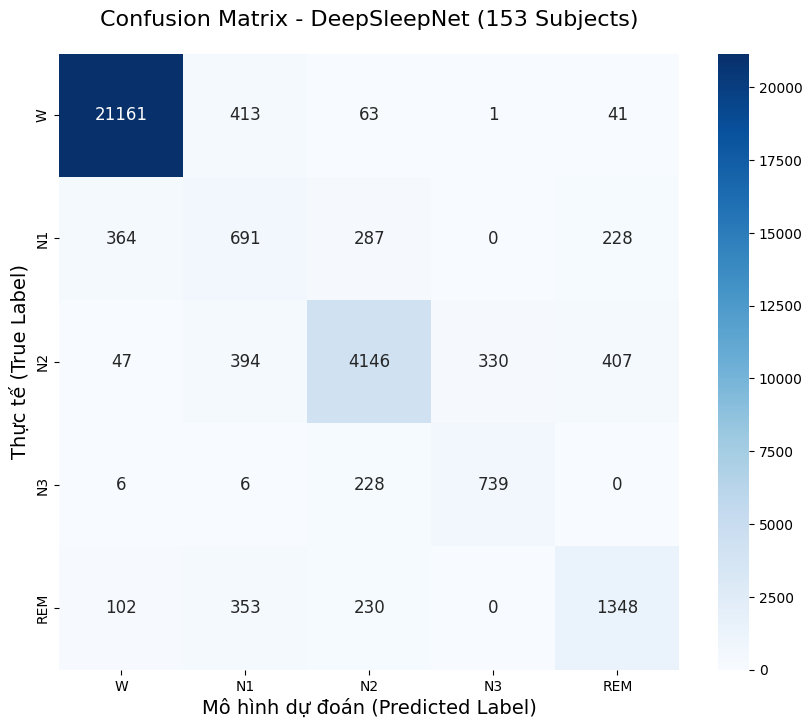

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load lại mô hình tốt nhất ở Epoch 15
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

class_names = ['W', 'N1', 'N2', 'N3', 'REM']

# 1. IN BÁO CÁO CHI TIẾT TỪNG LỚP
print("\n" + "="*50)
print("BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT)")
print("="*50)
report = classification_report(test_targets, test_preds, target_names=class_names, digits=4)
print(report)

# 2. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12})

plt.title('Confusion Matrix - DeepSleepNet (153 Subjects)', fontsize=16, pad=20)
plt.ylabel('Thực tế (True Label)', fontsize=14)
plt.xlabel('Mô hình dự đoán (Predicted Label)', fontsize=14)

plt.savefig('final_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n✅ Đã lưu biểu đồ thành file 'final_confusion_matrix.png'")
plt.show()